# MPhys Project Summary Notebook
Author: Elijah Gill

This Jupyter notebook is intended to act as a summary of the work done throughout my MPhys Project: Using PyTorch to Image Through a Multimode Optical Fibre.

The notebook follows the progress of the project in chronological order. With different sections highlighting the focus of the project at that point. The key sections include:
* Known fibre model
* Segmented Model
* Known Priors
* Compressive Sampling Model

The aim of this project is to be able to find the transmission matrix (TM) of a multimode optical fibre (MMF). Which defines how a fibre will effect an incoming field of light.


## Initialisation

Files (42) imported from USB.
Files (189) imported from USB.


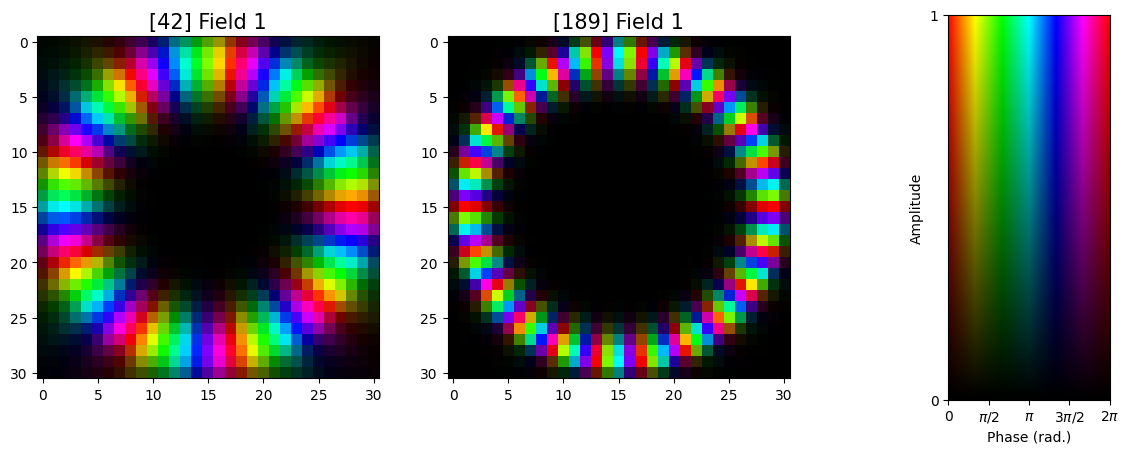

In [1]:
# Imports
from fibredata import *
from MPhys_functions import *
import torch.nn as nn
import IPython
from matplotlib import cm

# Check imports and data is working correctly by plotting one of the fields
visualise2(PIMs_torch[0], PIMs_torch189[0], "", "[42] Field 1", "[189] Field 1")

In [2]:
# Check if GPU is registered and being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

if torch.cuda.is_available():
    devNumber = torch.cuda.current_device()
    print(f"The current device number is {devNumber}")

    dev_name = torch.cuda.get_device_name(devNumber)
    print(f"GPU is {dev_name}")
else:
    print(f"No GPU available.")

device = torch.device("cpu")

Using Device: cuda
The current device number is 0
GPU is NVIDIA GeForce RTX 2060


In [ ]:
# Choose data (Imported from fibredata.py)
PIMs = PIMs_torch189
BETAs = beta_torch189

## Code Verification
The code was verified to be working as intended by looking at how PIMs behave when they are propagated through an MMF. When travelling through a perfectly straight fibre there should be no change in a PIM's shape, only its global phase should shift by a known amount found using its phase velocity.

Phase velocity of PIM 16: 14452986.089352548 m/s
Expected phase change: 2.6254659632998654 radians
Simulated phase change: 2.6207179402693184 radians


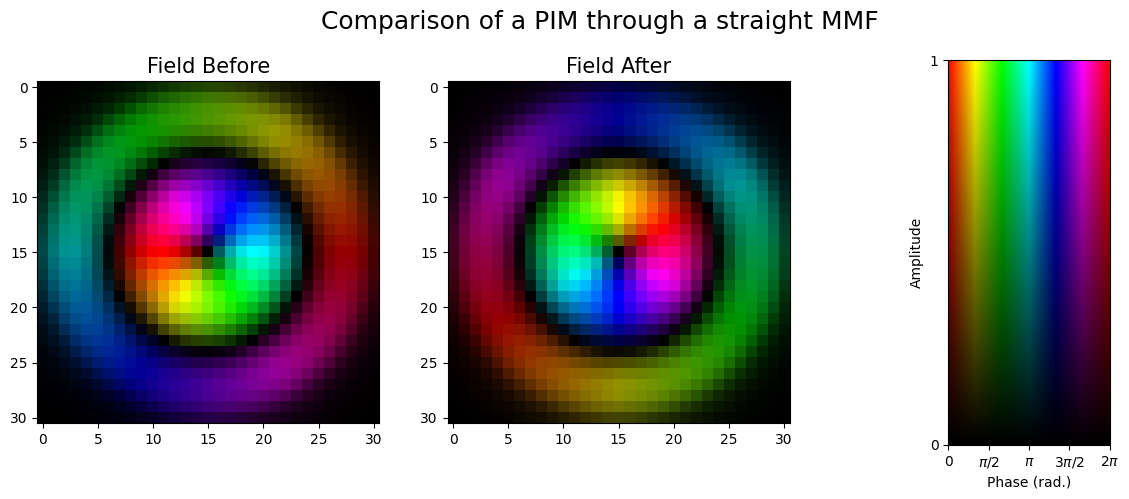

In [4]:
# Propagate a PIM through a straight segment of fibre, then observe its shape and phase change
mode, prop_dist = 16, 0.1
pim_start = norm(PIMs_torch[mode])
pim_end = norm(propagate_torch(pim_start, PIMs_torch, beta_torch, prop_dist))

visualise2(pim_start, pim_end, "Comparison of a PIM through a straight MMF", name="Propagation_verification.png", save=True)

print(f"Phase velocity of PIM {mode}: {beta_torch[mode].item()} m/s")
print(f"Expected phase change: {np.angle(np.exp(1j*beta_torch[mode].item()*prop_dist))%(2*np.pi)} radians")
print(f"Simulated phase change: {(torch.angle(pim_end[13,10])%(2*np.pi)-torch.angle(pim_start[13,10])).item()} radians")

The PIM indexed as '16' has a phase velocity of $14452986.089352548$ $ms^{-1}$. When travelling through 0.1m of straight fibre it is expected to gain a phase of $2.6254$ $rads$. The simulated model has a phase change of $2.6207$ $rads$, while also keeping its shape throughout propagation. From this, the propagation code is validated to be working correctly.

Zernike polynomials were used to represent bends in the fibre. The x and y tilt polynomials were used to represent extra phase changes dependent on the extra distance travelled. The angle of the plane requried to create an overall $2\pi$ phase change was calculated by hand, then this angle was passed to the code functions to verify it produces the same result.

The by hand calculation uses trigonometry to find the angle to be: $1.4509^o$

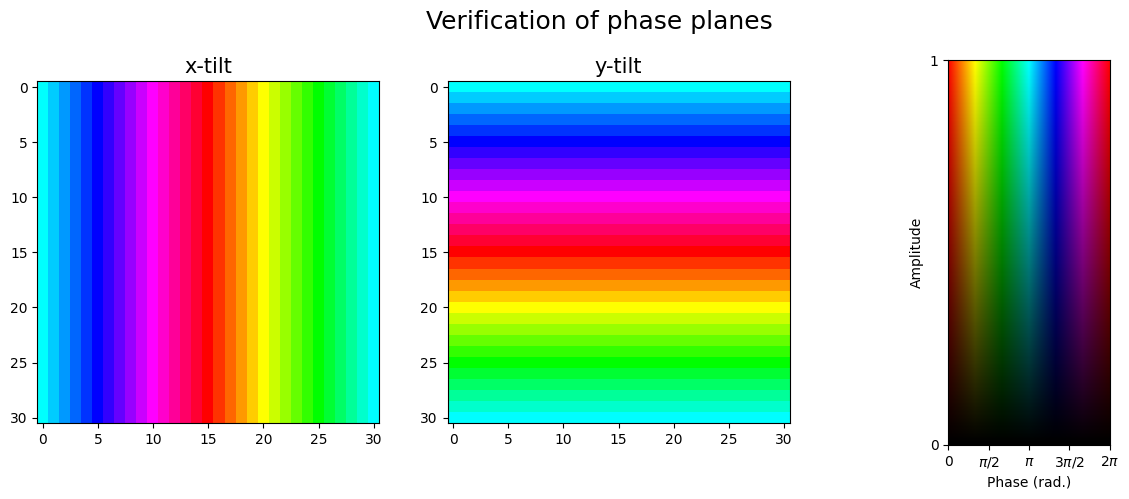

In [5]:
# Plot using functions
angle = torch.tensor([1.4509])
field = torch.ones(31,31)
xtilt = apply_zernike(field, 'x', angle)
ytilt = apply_zernike(field, 'y', angle)
visualise2(xtilt, ytilt, "Verification of phase planes", "x-tilt", "y-tilt", name="Bend_verification.png", save=True)

The plots show a smooth range between $-\pi$ and $\pi$, agreeing with the theory and verifying that the code is working properly.

When PIMs propagate through an imperfect MMF (such as a bent fibre) they couple to other modes with similar momenta. The plot below gives an example of the gaussian distribution used to represent this effect in this project, where the colour bar represents the normalised power of a PIM.

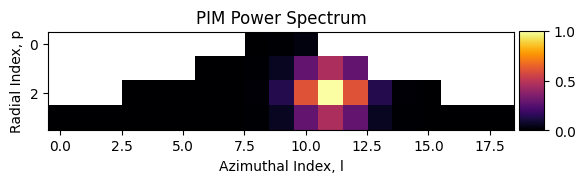

In [6]:
PP_spectrum_gauss(2, 1, 1, 0.8, uwlm)
plt.savefig("PP_spectrum_final.png", dpi=300)

Maximum image reconstruction possible depends on the number of eigenmodes of the fibre. The more PIMs an MMF has, the more information can be stored when propagating through the fibre. This work uses both 42 and 189 PIM fibres, with images reconstructed using 189 PIM fibre models due to the better image quality showing the capability of this technology. Scaling the models up to higher numbers of modes is possible, however it is expected to increase computing time to train the models.

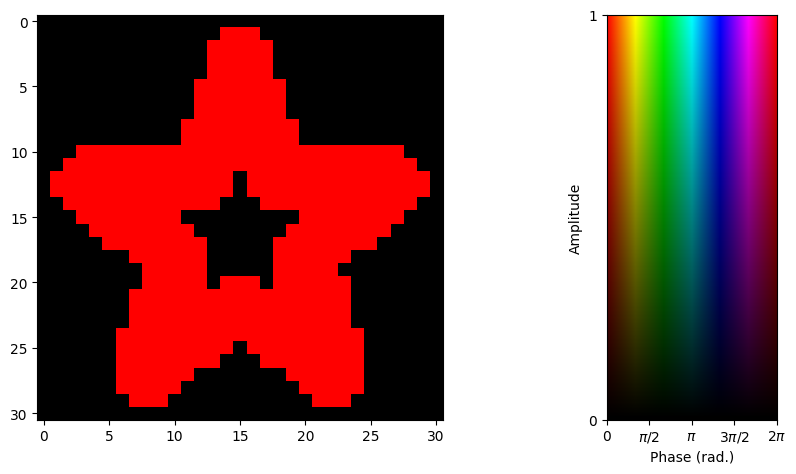

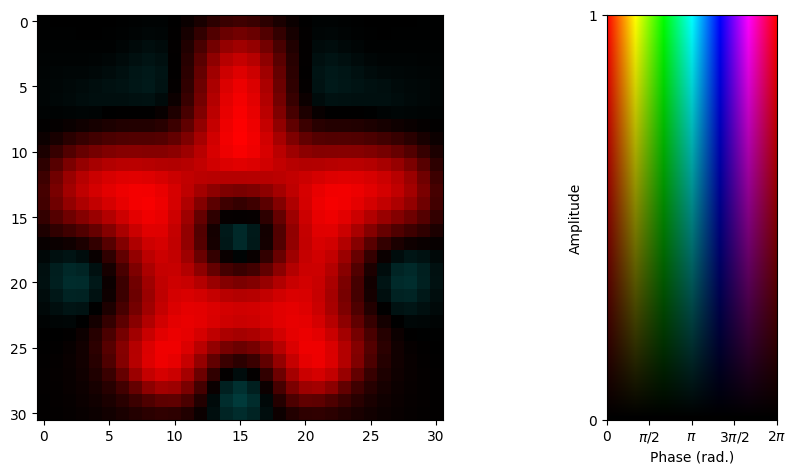

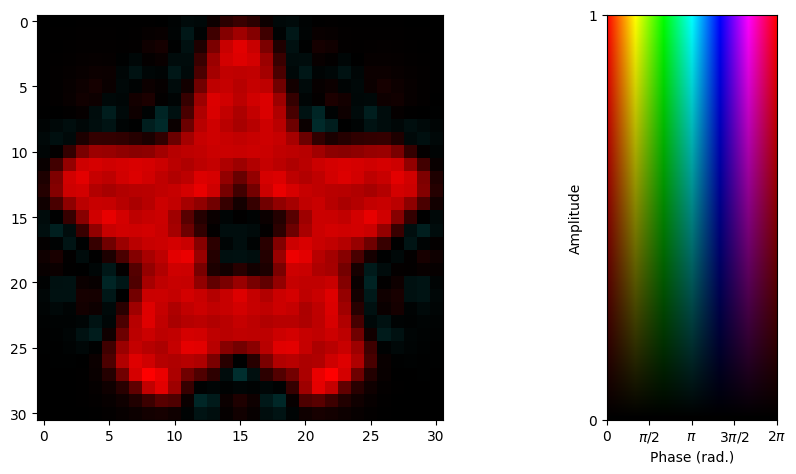

In [7]:
im = plt.imread("Images\\Star1.png")
im_torch = torch.from_numpy(1 - im)[:,:,0]
im_torch = im_torch.to(dtype=torch.cdouble)
visualise(im_torch, save=True)
pim_im = propagate_torch(im_torch, PIMs_torch, beta_torch)
visualise(pim_im)
pim_im = propagate_torch(im_torch, PIMs_torch189, beta_torch189)
visualise(pim_im)

## Known Fibre Model
Training data is required for the neural networks to converge on a solution. As I did not have access to real world data, I needed to create a model for a multimode optical fibre to generate this data. 

This was done by splitting an MMF into small, perfectly straight, segments separated by a plane which represents a bend in the fibre. Repeating this with enough segements can model more complex shapes of MMF.

Below is the class representing the known (real) fibre.

In [8]:
class KnownFibre:
    """Fibre class used to generate fields and TMs when parameters are fully known. Not intended for use in training."""
    def __init__(self, modes, betas, segment_len, bends):
    
        self.modes = modes
        self.betas = betas
        self.segment_len = segment_len
        self.bends = bends

        # Initialise the TM for the fibre
        self.tm_pim = self.TM(True)
        self.tm_real = self.TM()

    def TM(self, PIM_basis=False):
        """Generates the transmission matrix for the fibre using all available PIMs.
          Can return the TM in the real or PIM basis, defaulting to the real basis."""
        
        # Compute TM in real basis
        pim_mat = pim_matrix(self.modes)
        real_mat = real_matrix(self.modes)
        beta_mat = beta_matrix(self.betas, self.segment_len)
        segment_prop = real_mat @ (beta_mat @ pim_mat)

        # Compute the first straight segment propagation
        tm = segment_prop
        # Loop over all bends and apply the change due to bend + propagation
        if len(self.bends) > 0:
            for i in range(len(self.bends)):
                bend_vec_x = vectorise(zernike_array('x',torch.tensor([self.bends[i][0]])))
                bend_vec_y = vectorise(zernike_array('y', torch.tensor([self.bends[i][1]])))
                bend_diag_x = torch.diag(bend_vec_x.T[0])
                bend_diag_y = torch.diag(bend_vec_y.T[0])
                tm = segment_prop @ ((bend_diag_y @ bend_diag_x) @ tm)
        else:
            #print("No bend")
            pass
        
        # Return TM in specified format
        if PIM_basis == True:
            tm = pim_mat @ tm @ real_mat
        else: 
            pass
        
        return tm
    
    def forward_pix(self, input_field):
        """Propagates a field in pixel space through the fibre and returns the new field.
        A forward pass of the model."""
        return unvectorise(self.tm_real @ vectorise(input_field), self.modes[0].shape[0])
    
    def forward_pim(self, input_field):
        """Propagates a field in pim space through the fibre and returns the new field.
        A forward pass of the model."""
        return self.tm_pim @ input_field

Initialising the known fibre model, then passing input fields through it will generate the required training data. This exact training data is used in the final model presented in this document, but the KnownFibre class is used to generate all training data.

Fibre model initialised!


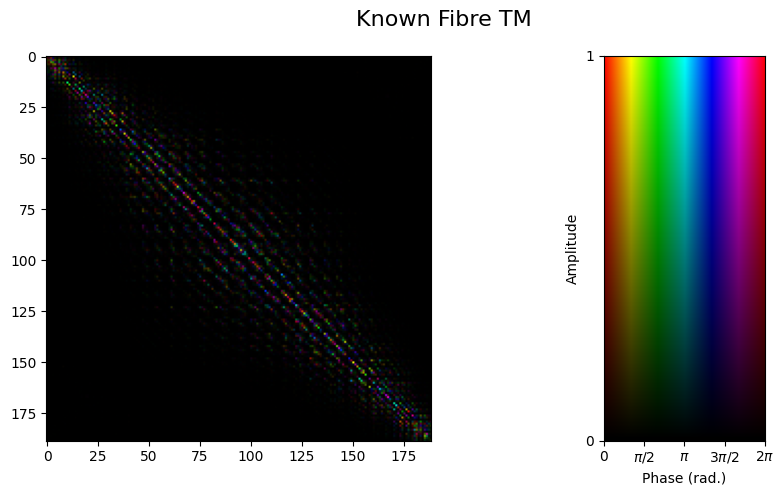

In [39]:
# Parameters of the MMF
pims = PIMs
betas = BETAs
pim_mat = pim_matrix(pims)
real_mat = real_matrix(pims)

# Initialise fibre model
# Segment Length [m]
segment_L = 0.01
# List of bends along the x and y axis, given in degrees
bends = [[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4]]
# Total fibre length
total_L = segment_L * (1 + len(bends))
# Make fibre model
fib = KnownFibre(pims, betas, segment_L, bends)
# Get known TM of the model (for later comparison)
true_TM = fib.TM(True)
visualise(true_TM, "Known Fibre TM")
print("Fibre model initialised!")

Both a set of input and target (output) fields are then generated using the "real" TM from this model and given to a different model as training data, to try and separately determine the known fibre's transmission matrix.

## Segmented Model
This model attempts to find the numerical values of the fibre (its length and bends) to then get the TM, similarly to the known fibre model, except without any known information of the length and bending in the fibre.

Below are the classes used for these models.

In [40]:
class LengthModel(nn.Module):

    def __init__(self, length=0.15):
        super(LengthModel, self).__init__()

        # Parameters
        self.length = nn.Parameter(data=torch.tensor([length], dtype=torch.float32, requires_grad=True))
    
    def forward(self, input_field):
        output_vector = TM(pims, betas, self.length) @ vectorise_torch(input_field)
        output_field = unvectorise_torch(output_vector,31)
        return output_field
    

class BendsModel(nn.Module):
    """Class to model a field propagation through an MMF with n number of bends."""
    def __init__(self, angles: np.ndarray=np.zeros((1,2)), prop_len: float=0.1):
        super(BendsModel, self).__init__()

        self.N = angles.shape[0]
        self.prop_len = prop_len
        # Parameters
        self.angles = nn.Parameter(data=angles.clone().detach(), requires_grad=True)
    
    def forward(self, input_field):
        """Forward pass of the model."""
        endsegment_field = input_field
        # For n bends, propagate and apply bends for each segment
        for i in range(self.N):
            prop_field = propagate_torch(endsegment_field, PIMs_torch, beta_torch, self.prop_len)
            bend_field = apply_zernike(prop_field, 'x', self.angles[i,0], wl, mask_len)
            endsegment_field = apply_zernike(bend_field, 'y', self.angles[i,1], wl, mask_len)
        # After all bends, propagate one more time
        output_field = propagate_torch(endsegment_field, PIMs_torch, beta_torch, self.prop_len)
        return output_field   

### Finding Length

In [41]:
# Making training data for a perfectly straight fibre
inputs_list, targets_list, index = random_ordered_fields(42, fib, 2)
input_data = torch.stack(inputs_list).to(device)
prop_dist = torch.tensor([0.2])
target_data = propagate_torch(input_data, pims, betas, prop_dist).to(device)

In [42]:
# Run model with an initial length guess of 0.15m
model = LengthModel(length=0.1).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 1000

for epoch in range(epochs):
    optimiser.zero_grad()
    output = model(input_data)

    loss = loss_fn(output, target_data)
    loss.backward()
    optimiser.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}, length: {model.length.item()}")

print(f"\nFinal Loss: {loss.item()}")
print(f"Final length: {model.length.item()}")

Epoch 0, Loss: 0.00041026321989559903, length: 0.10100000351667404
Epoch 100, Loss: 0.0004126300507443039, length: 0.09935914725065231
Epoch 200, Loss: 0.0004052429612048663, length: 0.09309647977352142
Epoch 300, Loss: 0.00037863313792200776, length: 0.083847776055336
Epoch 400, Loss: 0.00042260647427511746, length: 0.08170651644468307
Epoch 500, Loss: 0.0004388799970030965, length: 0.09181701391935349
Epoch 600, Loss: 0.00038070082876282983, length: 0.07873189449310303
Epoch 700, Loss: 0.00042648401398370843, length: 0.08159098029136658
Epoch 800, Loss: 0.0003965267684197037, length: 0.07128597050905228
Epoch 900, Loss: 0.000423546139381619, length: 0.08190430700778961

Final Loss: 0.0003659192144020174
Final length: 0.0773719772696495


The model is unable to converge, even with a good initial guess.

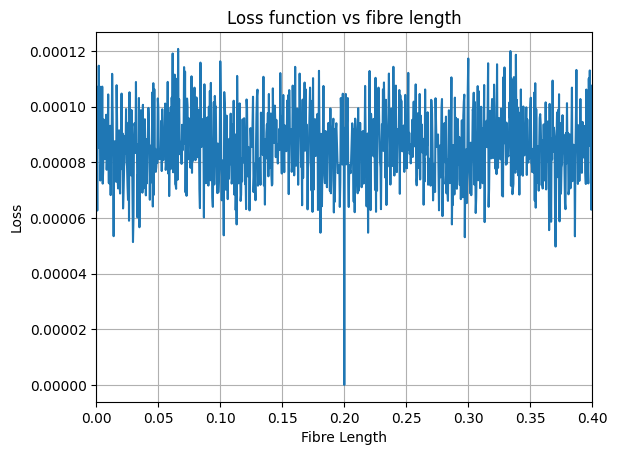

In [13]:
loss = []
xs = torch.linspace(0.0,0.4,1001)

for i in range(xs.size()[0]):
    model = LengthModel(length=xs[i]).to(device)
    fields_out = []
    for j in range(input_data.shape[0]):
        fields_out.append(model(input_data[j]))
    fields_out = torch.stack(fields_out)
    loss.append(loss_fn(fields_out, target_data).cpu().detach().numpy())

plt.plot(xs,loss)
# Make plot presentable
plt.title("Loss function vs fibre length")
plt.xlabel("Fibre Length"), plt.ylabel("Loss")
plt.xlim(0,0.4)
plt.grid(visible=True)

Looking at the loss function (how the loss varies with different fibre lengths, with L=0.2m as the true length). It is extremely noisy, with causes the optimiser to encounter many local minima and get stuck in one, returning an incorrect length.

### Finding angles
Next, the angles were attempted to be found (with perfect knowledge of the fibre's length).

In [16]:
# Making training data for an imperfect fibre
# Generate training data using this fibre setup
n = 21      # Amount of training fields
seed = 65   # Set to 0 for random fields
segment_len = 0.1
less_bends = [[0.5,0.4],[0.1,0],[0.2,0.7],[0.3,0.1],[0.8,0.4]]
simple_fib = KnownFibre(pims, betas, segment_len, less_bends)

# Make input and target data
inputs_list_simple, targets_list_simple, index = random_ordered_fields(n, simple_fib, seed)
inputs_simple = torch.stack(inputs_list_simple).to(device)
targets_simple = torch.stack(targets_list_simple).to(device)

Epoch 0, Loss: 0.001017519519021187, Bend 1: (0.009999551810324192, 0.009997648186981678), Bend 2: (0.009996944107115269, -0.009999368339776993), Bend 3: (0.009999056346714497, 0.0099998340010643)
Epoch 50, Loss: 0.00012147759419463458, Bend 1: (0.4505998194217682, 0.5057452917098999), Bend 2: (0.21545003354549408, -0.019697021692991257), Bend 3: (0.42598220705986023, 0.43840107321739197)
Epoch 100, Loss: 3.604180796652093e-07, Bend 1: (0.4991082549095154, 0.409166157245636), Bend 2: (0.10184190422296524, 0.005579051095992327), Bend 3: (0.2062114030122757, 0.6866234540939331)
Epoch 150, Loss: 4.425189320970854e-09, Bend 1: (0.5003758072853088, 0.399376779794693), Bend 2: (0.09969035536050797, 0.0005179115105420351), Bend 3: (0.19902212917804718, 0.7014306783676147)
Epoch 200, Loss: 1.5118068414128647e-11, Bend 1: (0.4999561011791229, 0.40003541111946106), Bend 2: (0.09998803585767746, 1.4949305295886006e-06), Bend 3: (0.20002414286136627, 0.699916422367096)

Final Loss: 1.6914712154256

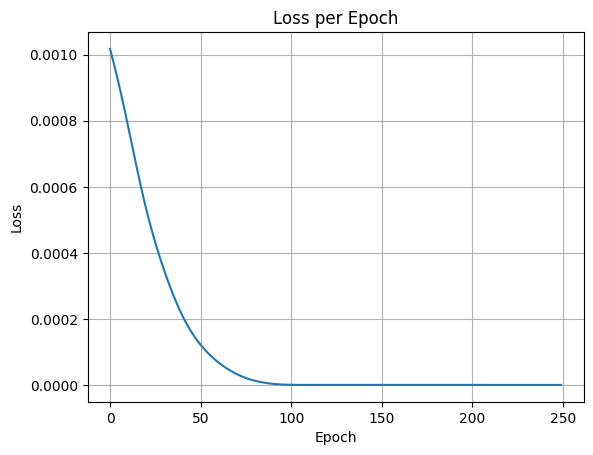

In [ ]:
class BendModelN(nn.Module):
    """Class to model a field propagation through an MMF with n number of bends."""
    def __init__(self, angles: np.ndarray=np.zeros((1,2)), prop_len: float=0.1):
        super(BendModelN, self).__init__()
        self.N = angles.shape[0]
        self.wl = 633e-9 #[m]  # From MATLAB Code
        self.mask_len = 25e-6 #[m]  # From MATLAB Code
        self.prop_len = prop_len
        # Parameters
        self.angles = nn.Parameter(data=torch.tensor(angles, dtype = torch.float32, requires_grad=True))
    
    def forward(self, input_field):
        """Forward pass of the model."""
        endsegment_field = input_field
        # For n bends, propagate and apply bends for each segment
        for i in range(self.N):
            prop_field = propagate_torch(endsegment_field, PIMs_torch, beta_torch, self.prop_len)
            bend_field = apply_zernike(prop_field, 'x', self.angles[i,0], self.wl, self.mask_len)
            endsegment_field = apply_zernike(bend_field, 'y', self.angles[i,1], self.wl, self.mask_len)
        # After all bends, propagate one more time
        output_field = propagate_torch(endsegment_field, PIMs_torch, beta_torch, self.prop_len)
        return output_field
    
# Angles
angles = np.array([[0.5,0.4],[0.1,0],[0.2,0.7],[0.3,0.1],[0.8,0.4]])
#angles = np.array([[0.1,0.8],[0.2,0.4],[0.9,0.4],[0.3,0.1],[0.5,0.3],[0.5,0.5],[0.1,0.7],[0.2,0.7],[0.3,0.8],[0.6,0.2]])
# Model
model = BendModelN(angles)
# Input fields
n = 10 # Number of fields
fields_in = PIMs_torch[:n]
# Make target fields
fields_target = []
for i in range(n):
    fields_target.append(model(fields_in[i]).detach())
fields_target = np.array(fields_target)
fields_target = torch.from_numpy(fields_target)
# Training loop
init_guesses = np.zeros((5,2))
model = BendModelN(init_guesses)#.to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-2)

epochs = 250
epoch_list = []
loss_list = []

for epoch in range(epochs):
    optimiser.zero_grad()
    
    # Make output data
    fields_out = []
    for k in range(n):
        fields_out.append(model(fields_in[k]))
    fields_out = torch.stack(fields_out)

    # Compute loss
    loss = loss_fn(fields_out, fields_target)

    # Backwards pass
    loss.backward()
    optimiser.step()
    epoch_list.append(epoch)
    loss_list.append(loss.detach().item())
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}, Bend 1: {model.angles[0,0].item(), model.angles[0,1].item()}, Bend 2: {model.angles[1,0].item(), model.angles[1,1].item()}, Bend 3: {model.angles[2,0].item(), model.angles[2,1].item()}")

print(f"\nFinal Loss: {loss.item()}")
print(f"Final Bend 1: {model.angles[0,0].item(), model.angles[0,1].item()}")
print(f"Final Bend 2: {model.angles[1,0].item(), model.angles[1,1].item()}")
print(f"Final Bend 3: {model.angles[2,0].item(), model.angles[2,1].item()}")
print(f"Final Bend 4: {model.angles[3,0].item(), model.angles[3,1].item()}")
print(f"Final Bend 5: {model.angles[4,0].item(), model.angles[4,1].item()}")

plt.plot(epoch_list, loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.grid(visible=True)


For simple fibre models, this training model works well!

By knowing the TM of the MMF, applying the inverse of the TM to an output field, in theory, should allow us to recreate the original image that was sent through the MMF.

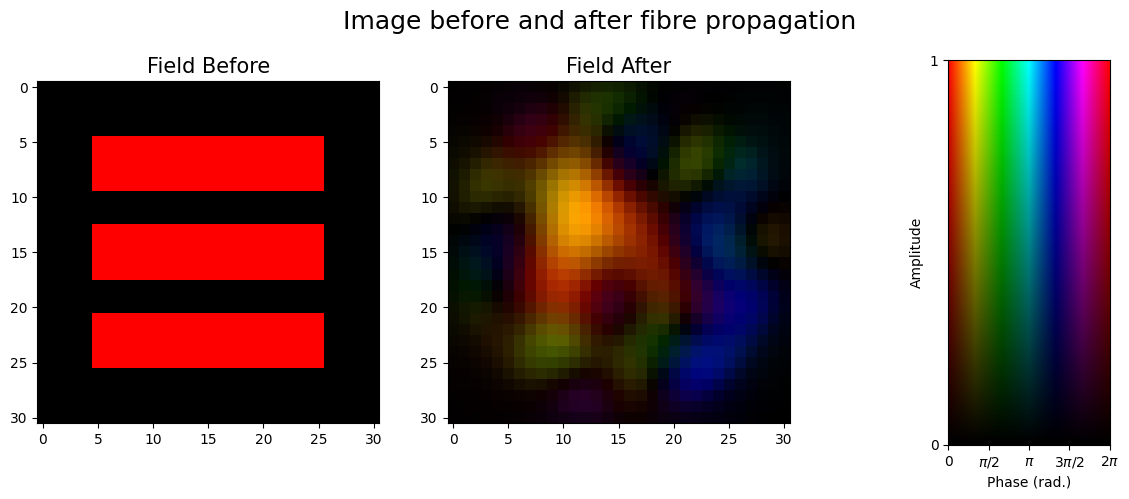

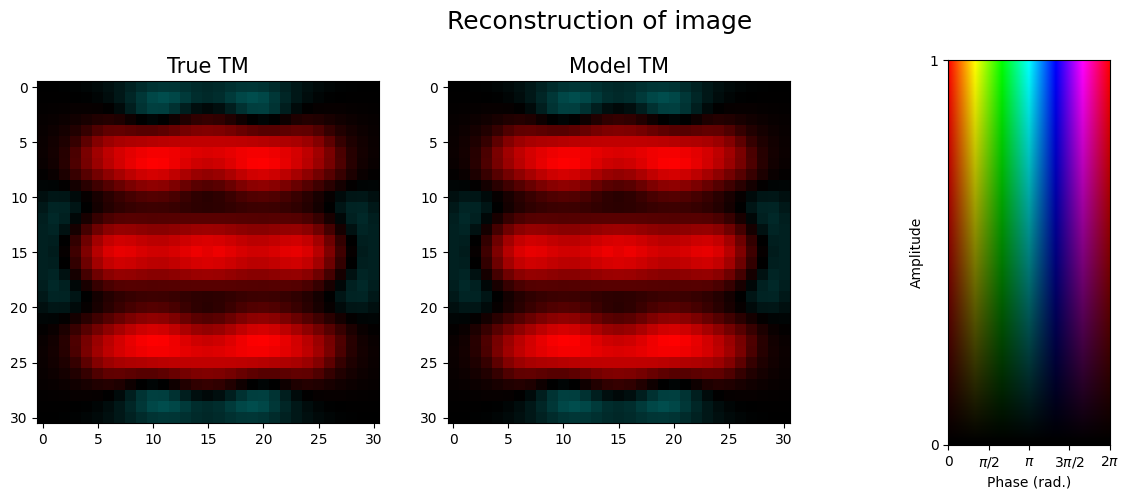

In [19]:
test = KnownFibre(pims,betas, 0.1, model.angles.detach())
c_fib = KnownFibre(pims,betas, 0.1, [[0.1,0.8],[0.2,0.4],[0.9,0.4],[0.3,0.1],[0.5,0.3],[0.5,0.5],[0.1,0.7],[0.2,0.7],[0.3,0.8],[0.6,0.2]])
test_TM_inv =  pixel_TM(pims, torch.linalg.inv(test.TM(True)))
c_TM_inv =  pixel_TM(pims, torch.linalg.inv(simple_fib.TM(True)))
# Pass an image through the fibre
image = image_to_field("3 hlines")
image_out = unvectorise(simple_fib.TM() @ vectorise(image),31)
visualise2(image, image_out, "Image before and after fibre propagation", name="Bend_Forward_Pass_Good.png", save=True)

# Run the inverse TM on the image for both the true TM and the model TM
true_inverse = unvectorise(c_TM_inv @ vectorise(image_out), 31)
model_inverse = unvectorise(test_TM_inv @ vectorise(image_out), 31)
visualise2(true_inverse, model_inverse, "Reconstruction of image", "True TM", "Model TM", name="Bend_Backward_Pass_Good.png", save=True)

Here, the inverse TM works well (as the TM is close to being unitary). It is able to reconstruct the original image to the maximum possible quality when only using 42 PIMs.

For a small number of bends, the correct parameters are able to be found, leading to a good estimate of the TM. However, when increasing the number of bends...

In [21]:
def plot_bendxy_loss(n, alpha, beta, l_bound, u_bound, num_points=100):
    """Returns a surface plot of the loss for a bend with both an x and y component.
    n = Number of Input Fields
    alpha, beta = Bend angles for x and y tilt respectively
    l_bound, u_bound = Lower and Upper bound for the grid
    num_points = Number of points on one axis of the grid (default is 100x100)"""

    # Compute loss for n fields
    model = BendsModel(torch.tensor([[alpha, beta]]))
    fields_in = PIMs_torch[:n]

    # Make target fields
    fields_target = []
    for i in range(n):
        fields_target.append(model(fields_in[i]).detach())
    fields_target = np.array(fields_target)
    fields_target = torch.from_numpy(fields_target)

    # Have a 100x100 surface plot for loss where x,y = alpha,beta and z = loss
    xs = np.linspace(l_bound, u_bound, num_points)
    ys = np.linspace(l_bound, u_bound, num_points)
    xs, ys = np.meshgrid(xs, ys)
    xs = torch.from_numpy(xs)
    ys = torch.from_numpy(ys)

    # Compute the loss for each point on the grid
    loss = np.empty(xs.shape)
    loss[:] = np.nan
    for i in range(xs.shape[0]):
        print(f"[{i}/{num_points}]")
        IPython.display.clear_output(wait=True)

        for j in range(xs.shape[0]):
            model = BendsModel(torch.tensor([[xs[i,j],ys[i,j]]]))
            
            # Make output data
            fields_out = []
            for k in range(n):
                fields_out.append(model(fields_in[k]).detach())
            fields_out = np.array(fields_out)
            fields_out = torch.from_numpy(fields_out)
            
            loss[i,j] = loss_fn(fields_out, fields_target).cpu().detach().numpy()

    fig = plt.figure(figsize=(20,5))
    fig.suptitle(r"Loss Function (True angles: $\alpha$="+str(alpha)+r", $\beta$="+ str(beta)+")", fontsize=18)
    # ================
    # First Subplot
    # ================
    ax = fig.add_subplot(1, 4, 1, projection='3d')
    surf = ax.plot_surface(xs,ys,loss, cmap=cm.jet)
    ax.set_title("Regular View")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    ax.set_zlabel("Loss")
    # ================
    # Directional Subplots
    # ================
    # z # top-down
    ax = fig.add_subplot(1, 4, 2, projection='3d')
    surf = ax.plot_surface(xs,ys,loss, cmap=cm.jet)
    fig.colorbar(surf, shrink=0.4, aspect=10)
    ax.view_init(elev=90, azim=0, roll=0)
    ax.zaxis.set_ticklabels([])
    ax.set_title("Top-down View")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    # x
    ax = fig.add_subplot(1, 4, 3, projection='3d')
    surf = ax.plot_surface(xs,ys,loss, cmap=cm.jet)
    fig.colorbar(surf, shrink=0.4, aspect=10)
    ax.view_init(elev=0, azim=0, roll=0)
    ax.xaxis.set_ticklabels([])
    ax.set_title(r"Side On View ($\beta$)")
    ax.set_ylabel(r"$\beta$")
    ax.set_zlabel("Loss")
    # y
    ax = fig.add_subplot(1, 4, 4, projection='3d')
    surf = ax.plot_surface(xs,ys,loss, cmap=cm.jet)
    fig.colorbar(surf, shrink=0.4, aspect=10)
    ax.view_init(elev=0, azim=-90, roll=0)
    ax.yaxis.set_ticklabels([])
    ax.set_title(r"Side On View ($\alpha$)")
    ax.set_xlabel(r"$\alpha$")
    ax.set_zlabel("Loss")

    plt.tight_layout
    fig.savefig("3D Loss Func.png", dpi=300)

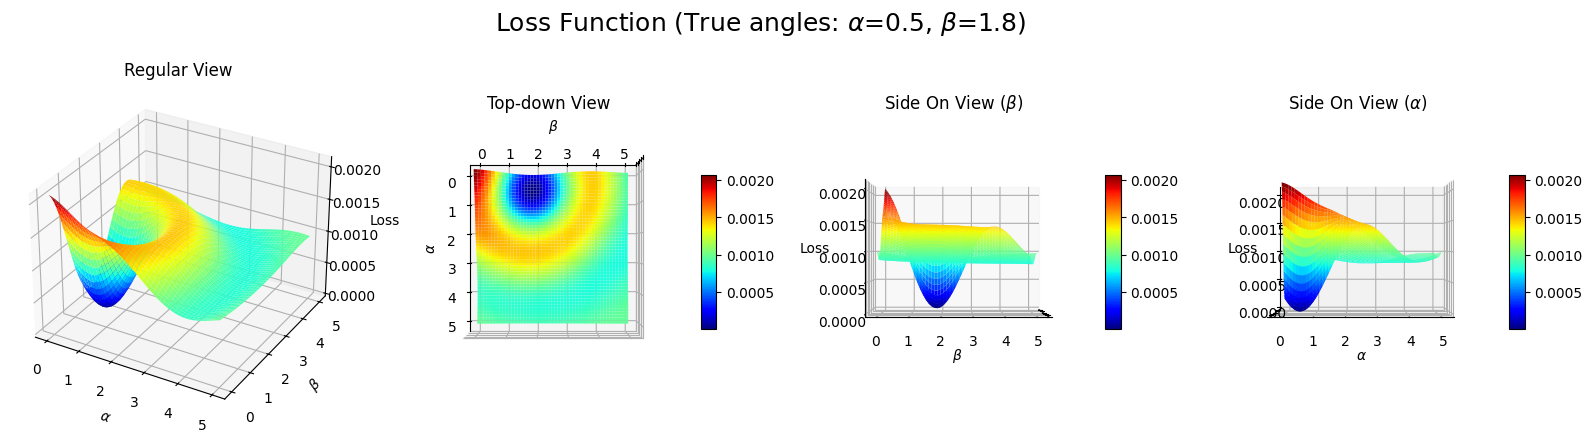

In [22]:
plot_bendxy_loss(5, 0.5, 1.8, 0, 5, 50)

This method is not suitable for finding the TM of a real world fibre as its limited number of allowed bends prohibits more detailed fibre models from being determined. The loss function for a single bend (x and y angles) is shown above, more complicated loss functions cannot be easily visualised as the number of dimensions increases. But it can be seen that the loss function will become noiser with more bends needing to be determined, creating the same problem as with finding the length.

## Known Priors
A model that tries to determine the parameters of a fibre creates too noisy loss functions to reliably travel through, especially as a fibre model becomes more complex to mimic reality. Instead, the TM itself can be set as a parameter of the training model. Theoretically, the TM can be completely sampled by sending in every PIM the fibre can hold, then using the output fields to form the TM, however this can become time consuming for fibres with a larger number of PIMs.

Utilising prior knowledge about the structure of the TM by building it into the model's loss function can greatly reduce the number of requried measurements needed to get a good measurement of a fibre's TM.

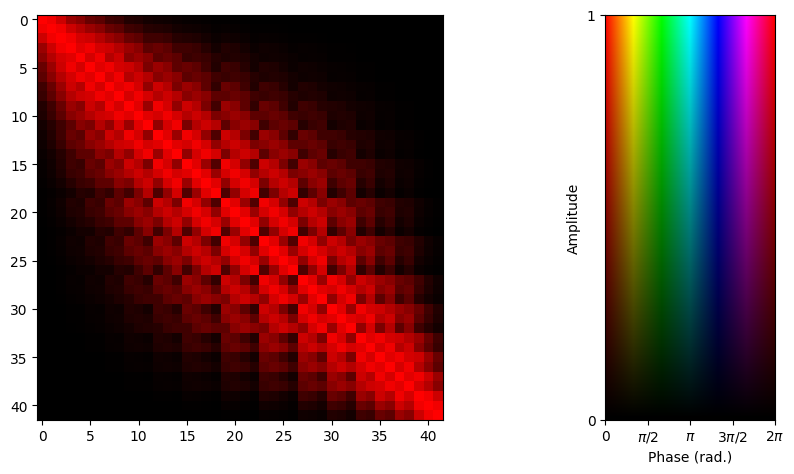

In [23]:
visualise(sampled_TM(3,2, uwlm))

This is called the estimated support matrix, and can be passed to the loss function to ensure that the determined TM has this shape by punishing any power that would lie outside of the allowed range.

## Compressive Sampling Model
The known priors are used in this model to directly determine the TM. Below is the model class used to do this.

In [11]:
class FibreModel(nn.Module):
    """Class to model a field propagation through an MMF with n number of bends. Intended for use in model training."""
    def __init__(self, modes, tm):
        super(FibreModel, self).__init__()
        self.pim_mat = pim_matrix(modes)
        self.real_mat = real_matrix(modes)
        # Parameters
        self.TM = nn.Parameter(data=tm.clone().detach(), requires_grad=True)
    
    def forward(self, vec_input_field):
        """Forward pass of the model."""
        output_field = self.TM @ vec_input_field

        return output_field, self.TM

### Make training data

Fibre model initialised!


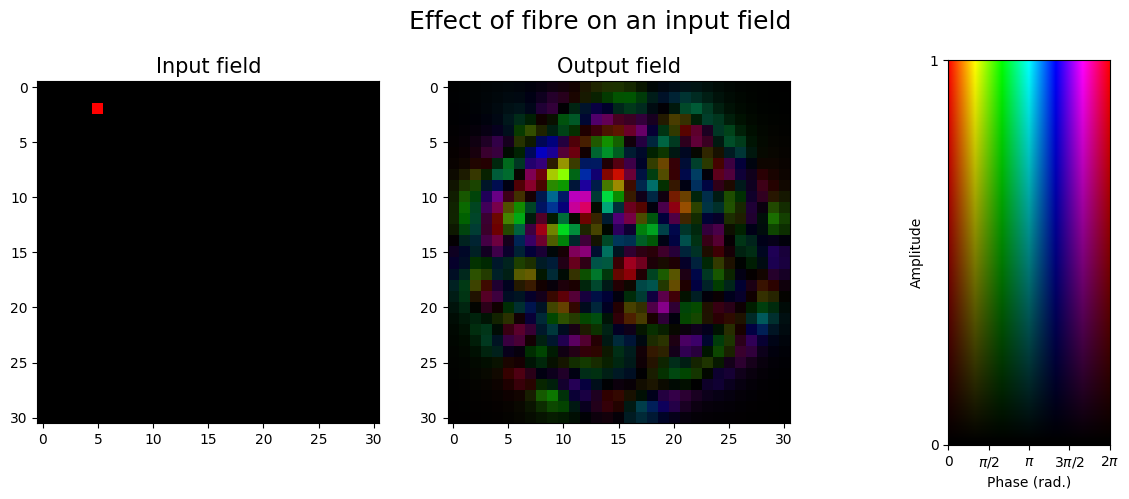

In [153]:
# Parameters of the MMF
pims = PIMs
betas = BETAs
pim_mat = pim_matrix(pims)
real_mat = real_matrix(pims)

# Initialise fibre model
# Segment Length [m]
segment_L = 0.01
# List of bends along the x and y axis, given in degrees
bends = [[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3]]#,[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4]]
#bends = [[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.9,0.2]]
# Total fibre length
total_L = segment_L * (1 + len(bends))
# Make fibre model
fib = KnownFibre(pims, betas, segment_L, bends)
# Get known TM of the model (for later comparison)
true_TM = fib.TM(True)
print("Fibre model initialised!")

# Estimated support vector
#w_pim = sampled_TM(3,2, uwlm).to(dtype=dtype) # For 42 modes
w_pim = sampled_TM(4,2, uwlm189).to(dtype=dtype) # For 189 modes

# Regularisation strength
#lamb = 0.01 # For 42 modes
lamb = 0.25 # For 189 modes

# Generate training data using this fibre setup
n = 189      # Amount of training fields
seed = 65   # Set to 0 for random fields

# Make input and target data
inputs_list, targets_list, index = random_ordered_fields(n, fib, seed)
inputs = torch.stack(inputs_list)
targets = torch.stack(targets_list)

# Plot an example of an input and output field from the known fibre model
visualise2(inputs[15],targets[15],"Effect of fibre on an input field", "Input field", "Output field")

# Format training data
# As 1 pixel input fields are being used, there is no need to normalise the fields
# Vectorise input and target fields
inputs = vectorise_torch(inputs)
targets = vectorise_torch(targets)

# Convert fields to PIM basis (smaller TM in PIM basis -> Faster + More reliable training)
inputs = pim_mat @ inputs
targets = pim_mat @ targets

# Initial guess of the TM (0 bends)
TM_guess = beta_matrix(betas, total_L)

The TM of this fibre is visually represented in the PIM basis below.

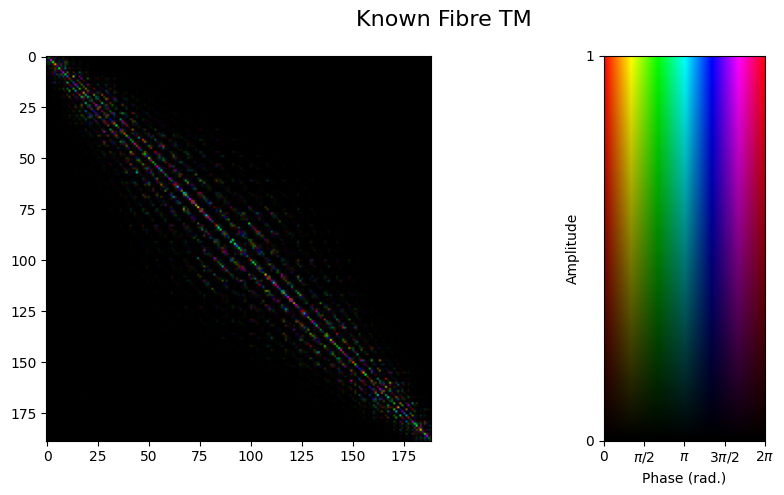

In [154]:
visualise(true_TM, "Known Fibre TM")

Perform the training loop

Epoch 0, Loss: 0.001581407208104073, Overlap: 0.2510662519241247
Epoch 100, Loss: 2.2930928078185428e-05, Overlap: 0.9880439122877201

Final Loss: 2.2840519752871748e-05
Overlap: 0.9880534391508478


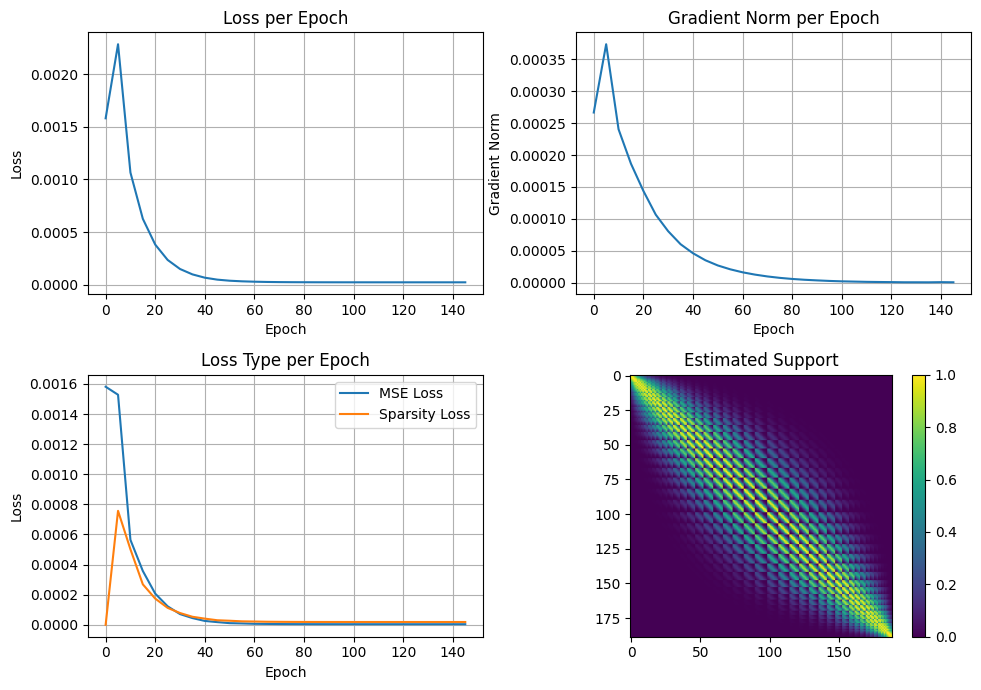

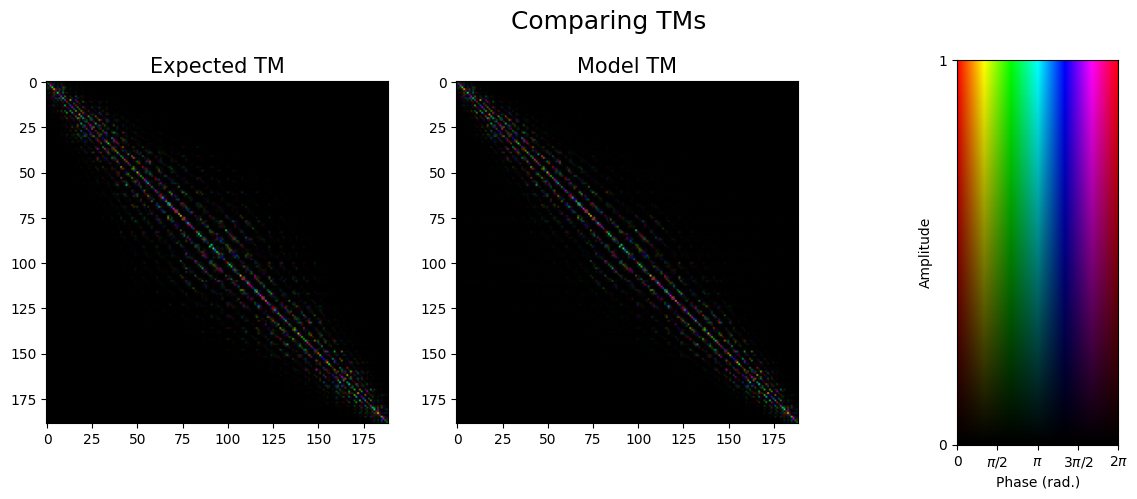

In [157]:
# Port stuff to GPU
inputs = inputs.to(device)
targets = targets.to(device)
w = w_pim.to(device)
pims = pims.to(device)
betas = betas.to(device)

# Initialise Optimiser
model = FibreModel(pims, TM_guess).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-1)

epochs = 150
previous_loss = 100
epoch_list = []
loss_list = []
angles_list = []
grad_norm_list = []
l_list = []
sparse_l_list = []

# Training Loop
for epoch in range(epochs):
    optimiser.zero_grad()

    # Make output data
    outputs, epoch_TM = model(inputs)

    # Compute loss
    loss, l, sl = sparsity_loss(targets, outputs, lamb, w, epoch_TM)
    previous_loss = loss
    # Backwards pass
    loss.backward()
    optimiser.step()

    if epoch % 5 == 0:
        epoch_list.append(epoch)
        loss_list.append(loss.detach().item())
        grad_norm_list.append(model.TM.grad.norm().item())
        l_list.append(l.detach().item())
        sparse_l_list.append(sl.detach().item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}, Overlap: {overlap(true_TM, epoch_TM)}")

# ============================================ End Loop ==================================================

print(f"\nFinal Loss: {loss.item()}")

# Print overlap integral
print(f"Overlap: {overlap(fib.TM(True), epoch_TM.detach().cpu())}")

# Plots
fig, axs = plt.subplots(2,2, figsize=(10,7))

axs[0,0].plot(epoch_list, loss_list), axs[0,0].grid(visible=True), axs[0,0].set_xlabel("Epoch"), axs[0,0].set_ylabel("Loss"), axs[0,0].set_title("Loss per Epoch")
axs[0,1].plot(epoch_list, grad_norm_list), axs[0,1].grid(visible=True), axs[0,1].set_xlabel("Epoch"), axs[0,1].set_ylabel("Gradient Norm"), axs[0,1].set_title("Gradient Norm per Epoch")
axs[1,0].plot(epoch_list, l_list, label="MSE Loss"), axs[1,0].plot(epoch_list, sparse_l_list, label="Sparsity Loss"), axs[1,0].grid(visible=True), axs[1,0].legend(), axs[1,0].set_xlabel("Epoch"), axs[1,0].set_ylabel("Loss"), axs[1,0].set_title("Loss Type per Epoch")
esti = axs[1,1].imshow(w.cpu().to(torch.float))
plt.colorbar(esti), axs[1,1].set_title("Estimated Support")

plt.tight_layout()
fig.savefig("Comp_loss_graphs.png", dpi=300)
visualise2(fib.TM(True), epoch_TM.detach().cpu(), "Comparing TMs", "Expected TM", "Model TM", name="Comp_TMs.png", save=True)

There is good agreement between the ground truth TM and optimised TM, but it does not reach the same quality as previous models (when they worked). Despite this it is much more reliable than the other methods.

Attempting to reconstruct images using 189 PIMs.

0.9881834720360233
0.9865151887528778
0.9866433976510526
tensor(0.9881, dtype=torch.float64)


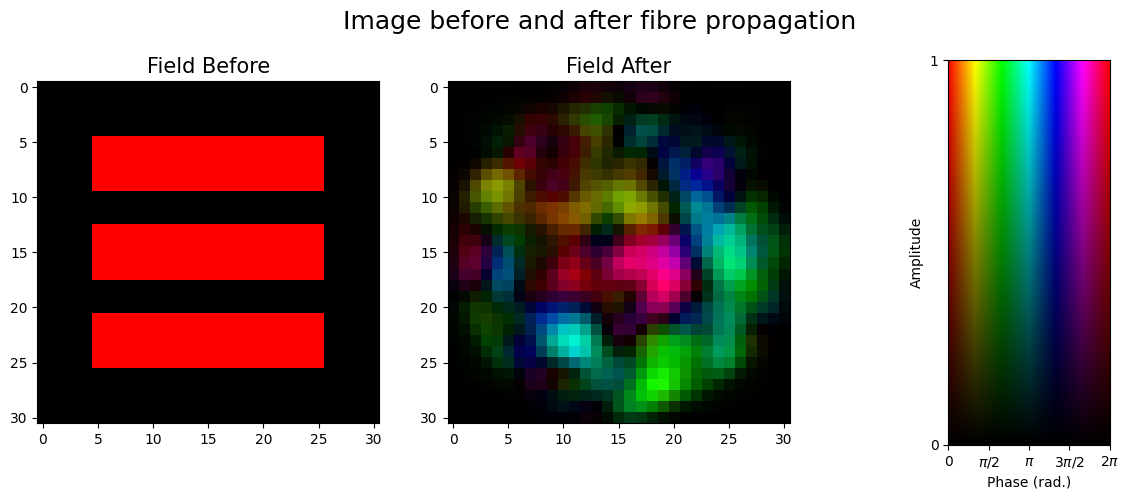

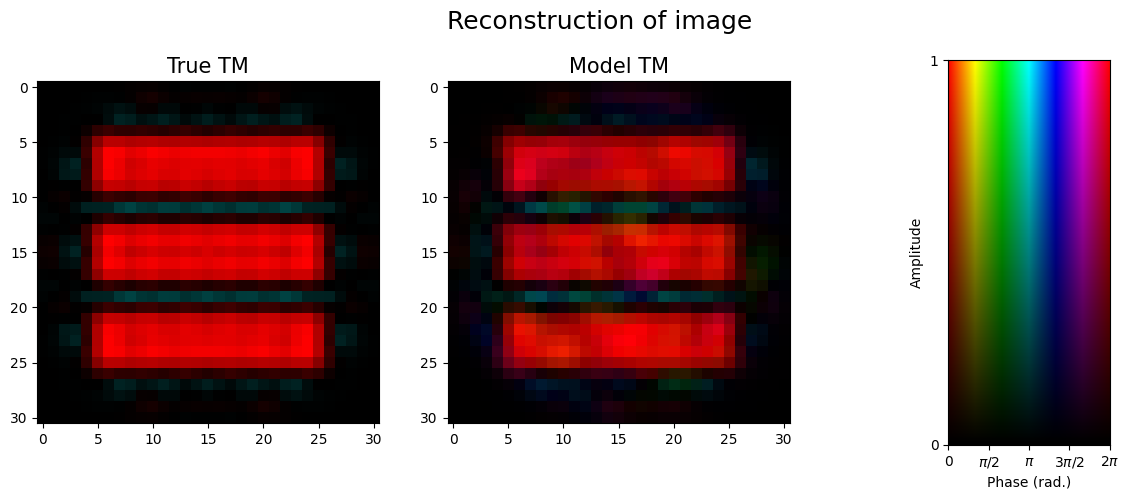

In [158]:
# Generate pixel TMs
pix_tm_model = pixel_TM(pims, epoch_TM.detach().cpu())
pix_tm_true = fib.TM()
#inv_tm_model = pixel_TM(pims, epoch_TM.detach().cpu().conj().T)
inv_tm_true = pixel_TM(pims.cpu(), torch.linalg.inv(true_TM))
inv_tm_model = pixel_TM(pims.cpu(), torch.linalg.inv(epoch_TM.detach().cpu()))

# Pass an image through the fibre
image = image_to_field("3 hlines")
image_out = unvectorise(pix_tm_true @ vectorise(image),31)
visualise2(image, image_out, "Image before and after fibre propagation")

# Run the inverse TM on the image for both the true TM and the model TM
true_inverse = unvectorise(inv_tm_true @ vectorise(image_out), 31)
model_inverse = unvectorise(inv_tm_model @ vectorise(image_out), 31)
visualise2(true_inverse, model_inverse, "Reconstruction of image", "True TM", "Model TM", name="Comp_Recon_189.png", save=True)

print(overlap(pix_tm_model, pix_tm_true).item())
print(overlap(inv_tm_model, inv_tm_true).item())
print(overlap(torch.linalg.pinv(epoch_TM.detach().cpu(), rcond=1e-1), torch.linalg.pinv(fib.TM(True), rcond=1e-1)).item())
print(overlap(fib.TM(True).conj().T, epoch_TM.detach().cpu().conj().T))

This model works well, providing good agreement with the expected TM and is able to converge very quickly.

# Compression Ratio
Plotting the overlap between the expected and generated TMs for different numbers of probes used, allows for a good visualisation of how well this model works.

In [28]:
# Compression ratio plot initialisation
pims = PIMs_torch189
betas = beta_torch189
pim_mat = pim_matrix(pims)
real_mat = real_matrix(pims)

if pims.shape[0] == 42:
    num_modes = [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42]
elif pims.shape[0] == 189:
    num_modes = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180]
else:
    print("Couldn't assign modes!")
    
c_ratio = []
for i,mode in enumerate(num_modes):
    c_ratio.append(mode/pims.shape[0])

repeats = 100
seed = 0    # Set to 0 for random fields

# Fibre parameters
segment_L = 0.01
#bends = [[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3]]
#bends = [[0.5,0.1],[0.5,0.2],[0.5,0.3],[0.5,0.4],[0.5,0.5],[0.5,0],[0.5,0.25],[0.5,0.48],[0.5,0.11],[0.5,0.78],[0.5,0.1],[0.5,0.2],[0.5,0.3],[0.5,0.4],[0.5,0.5],[0.5,0],[0.5,0.25],[0.5,0.48],[0.5,0.11],[0.5,0.3]]
bends = [[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.9,0.2]]
# Total fibre length
total_L = segment_L * (1 + len(bends))
# Make fibre
fib = KnownFibre(pims, betas, segment_L, bends)
# Define correct fibre TM
TM_correct = fib.TM(True)

# Initial guess of the TM (0 bends)
TM_guess = beta_matrix(betas, total_L)

# Training
if pims.shape[0] == 42:
    lamb = 0.01 # For 42 modes
    w = sampled_TM(3,1, uwlm).to(dtype=dtype).to(device)
elif pims.shape[0] == 189:
    lamb = 0.25 # For 189 modes
    w = sampled_TM(4,2, uwlm189).to(dtype=dtype)
else:
    lamb = 0.1 
    print("Couldn't assign lambda value!")
    
epochs = 150

In [29]:
data = []
for i,modes in enumerate(num_modes):
    overlaps = []
    for j in range(repeats):
        # Print iteration
        print(f"Computing Model {(i*repeats)+j+1}/{len(num_modes)*repeats}")
        IPython.display.clear_output(wait=True)

        # Amount of training fields
        n = modes      

        # Make input and target data
        inputs_list, targets_list, index = random_ordered_fields(n, fib, seed)
        inputs = torch.stack(inputs_list)
        targets = torch.stack(targets_list)

        # Vectorise input and target fields
        inputs = vectorise_torch(inputs)
        targets = vectorise_torch(targets)

        # Convert fields to PIM basis
        inputs = pim_mat @ inputs
        targets = pim_mat @ targets

        # ====================================================================================================================================
        #                                                      Training Code
        # ====================================================================================================================================

        # Port stuff to GPU
        inputs = inputs.to(device)
        targets = targets.to(device)
        pims = pims.to(device)
        betas = betas.to(device)

        # Initialise Optimiser
        model = FibreModel(pims, TM_guess).to(device)
        optimiser = torch.optim.Adam(model.parameters(), lr=1e-1)

        previous_loss = 100

        # Training loop
        for epoch in range(epochs):
            optimiser.zero_grad()
            
            # Make output data
            outputs, epoch_TM = model(inputs)
            # Compute loss
            loss, l, sl = sparsity_loss(targets, outputs, lamb, w, epoch_TM)
            # Backwards pass
            loss.backward()
            optimiser.step()

        # Save overlap data
        overlaps.append(overlap(TM_correct, epoch_TM.detach().cpu()))
    
    data.append([modes, overlaps])

Computing Model 1800/1800


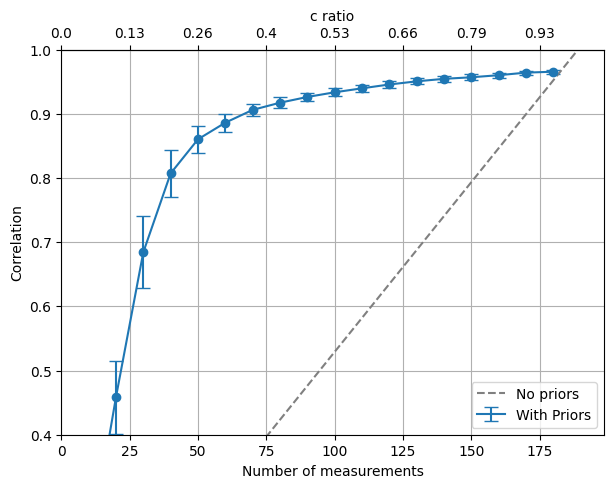

In [ ]:
# Process data
# Find average power ratio
avg_data = []
errs = []
mds = []
for i,dat in enumerate(data):
    avg_data.append((sum(dat[1])/len(dat[1])).item())
    errs.append(np.std(dat[1],ddof=1))
    mds.append(dat[0])

# Plot data
fig, axs = plt.subplots(1,1, figsize=(7,5))
axs.grid(visible=True)
axs.scatter(mds, avg_data, zorder=3)
axs.errorbar(mds, avg_data, yerr=errs, zorder=2, capsize=5, label="With Priors")
axs.plot([0,189],[0,1], linestyle="--", label="No priors",c="gray")
#axs.set_title("Compressively Sampled TM Fidelity")
axs.set_ylabel("Correlation"), axs.set_xlabel("Number of measurements")
axs.set_ybound(0.4,1.0), axs.set_xbound(0, None)

if pims.shape[0] == 42:
    axs.set_xticks(np.arange(0,43,6))
    top_xaxis = axs.secondary_xaxis('top')
    top_xaxis.set_xticks(np.arange(0,43,6), labels=np.round(np.arange(0,43,6)/42,2)) 
elif pims.shape[0] == 189:
    axs.set_xticks(np.arange(0,189,25))
    top_xaxis = axs.secondary_xaxis('top') 
    top_xaxis.set_xticks(np.arange(0,189,25), labels=np.round(np.arange(0,189,25)/189,2)) 
top_xaxis.set_xlabel("c ratio")

axs.legend(loc="lower right")

The compression ratio, which measures the ratio between the number of measurements taken and the maximum number of measurements needed to fully sample the TM (equal to the number of PIMs a fibre can hold), can be used to compare how well the compressive sampling model works against columnwise reconstruction of the TM. The result is that the compressive sampling model is capable of generating a TM with much higher correlation with the ground truth model, with much less input data than only using columnwise reconstruction (no priors).

# Recreating Images
Now that a model to find the TM of a fibre is working correctly, images can be recovered by reversing the determined TM.

The process used to get the images in this section:
1) Determine the TM of the KnownFibre model
    * Convert it to the real basis
2) Pass an image through the KnownFibre model
    * Plot the before and after images
3) Multiply the output image by the inverse of the FibreModel TM
    * Reconstruct image using both inverse TMs and compare

For better image quality, a fibre with a higher number of PIMs (189) is chosen. The model is trained at a compression ratio of c=0.53 .


In [36]:
# Parameters of the 189 mode MMF
pims = PIMs_torch189
betas = beta_torch189

# Initialise fibre model
# Segment Length [m]
segment_L = 0.01
# List of bends along the x and y axis, given in degrees
bends = [[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4]]
#bends = [[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3]]
#bends = [[0.5,0.1],[0.5,0.2],[0.5,0.3],[0.5,0.4],[0.5,0.5],[0.5,0],[0.5,0.25],[0.5,0.48],[0.5,0.11],[0.5,0.78],[0.5,0.1],[0.5,0.2],[0.5,0.3],[0.5,0.4],[0.5,0.5],[0.5,0],[0.5,0.25],[0.5,0.48],[0.5,0.11],[0.5,0.3]]
#bends = [[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4]]
#bends = [[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.6],[0.4,0.3],[0.5,0.4],[0.5,0.4],[0.9,0.2]]
# Total fibre length
total_L = segment_L * (1 + len(bends))
# Make fibre model
fib = KnownFibre(pims, betas, segment_L, bends)
# Get known TM of the model (for later comparison)
true_TM = fib.TM(True)
print("Fibre model initialised!")

# Training data #38,76,114,152,189
n = 40
inputs, targets, w_pim, lamb, inputs_list = make_training_data(n, pims, fib, 65)
w_pim = sampled_TM(4,2, uwlm189)
# Initial guess of the TM (0 bends)
TM_guess = beta_matrix(betas, total_L)

Fibre model initialised!


Epoch 0, Loss: 0.0012659817004752993, Overlap: 0.25934411503327937
Epoch 100, Loss: 1.0290086022091958e-05, Overlap: 0.9103796255292685

Final Loss: 8.50850404787273e-06
Overlap: 0.9388144141428225


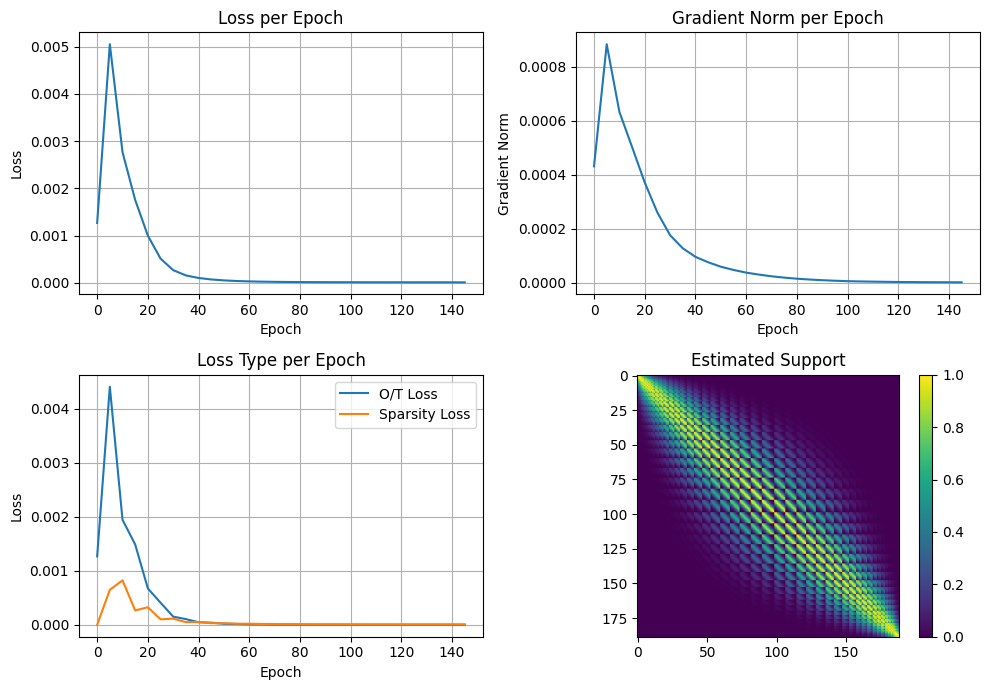

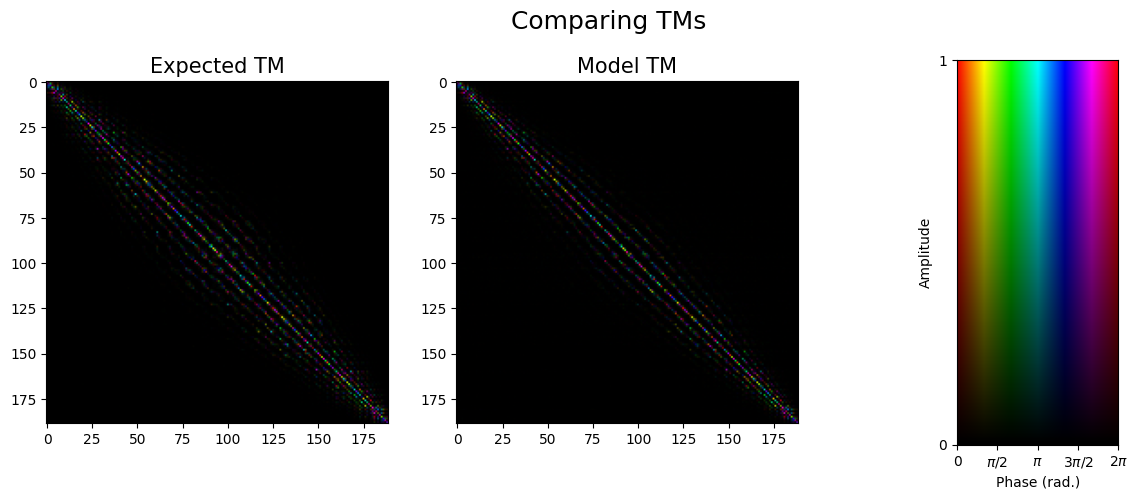

In [37]:
model_TM = train_model(inputs, targets, w_pim, pims, betas, FibreModel(pims, TM_guess), lamb, device, true_TM, 150)

0.939013757526321
0.8041581513774317
0.8048584646171504


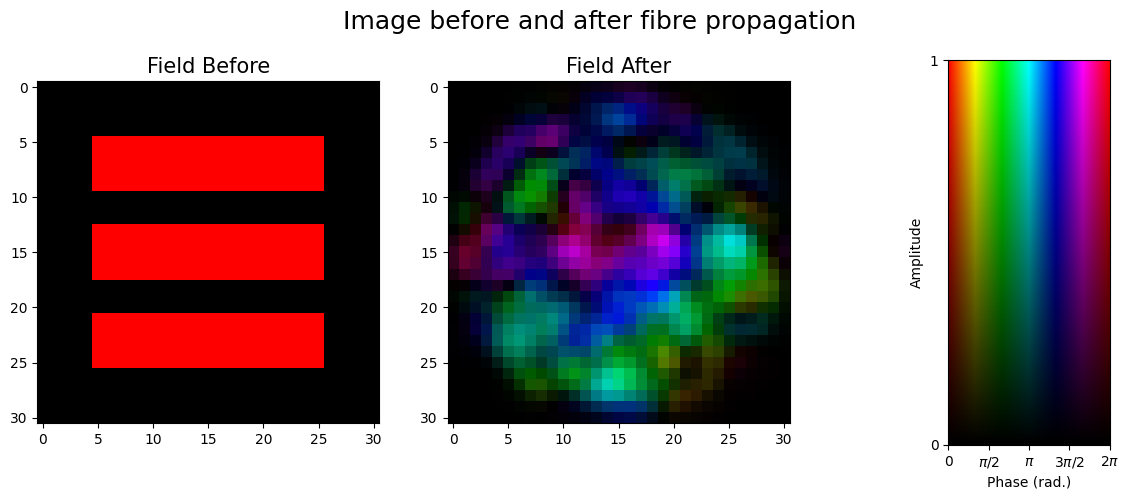

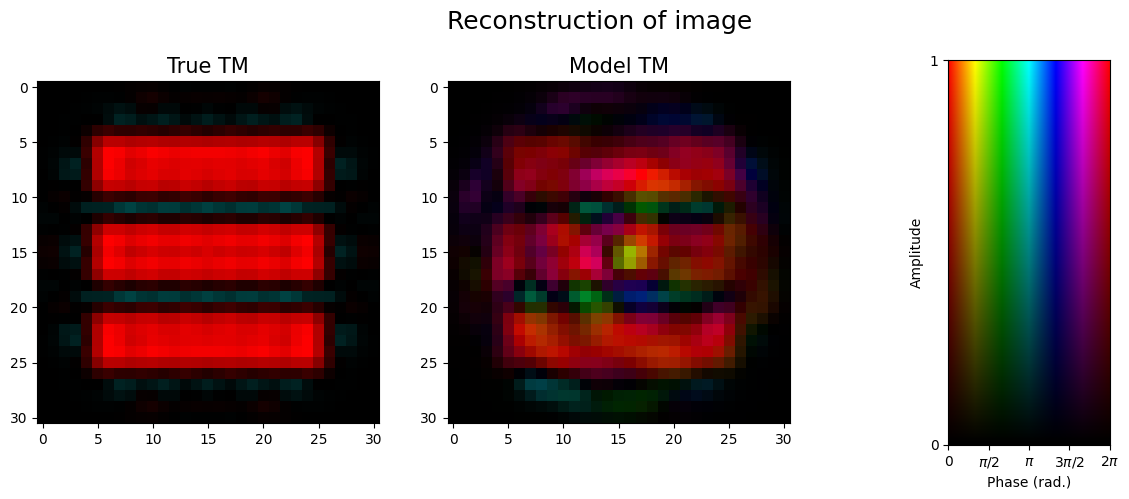

In [38]:
# Generate pixel TMs
pix_tm_model = pixel_TM(pims, model_TM)
pix_tm_true = fib.TM()
inv_tm_model = pixel_TM(pims, torch.linalg.inv(model_TM))
inv_tm_true = pixel_TM(pims.cpu(), torch.linalg.inv(true_TM))

print(overlap(pix_tm_model, pix_tm_true).item())
print(overlap(inv_tm_model, inv_tm_true).item())
print(overlap(torch.linalg.inv(model_TM), torch.linalg.inv(fib.TM(True))).item())

# Pass an image through the fibre
image = image_to_field("3 hlines")
image_out = unvectorise(pix_tm_true @ vectorise(image),31)
visualise2(image, image_out, "Image before and after fibre propagation")

# Run the inverse TM on the image for both the true TM and the model TM
true_inverse = unvectorise(inv_tm_true @ vectorise(image_out), 31)
model_inverse = unvectorise(inv_tm_model @ vectorise(image_out), 31)
visualise2(true_inverse, model_inverse, "Reconstruction of image", "True TM", "Model TM")

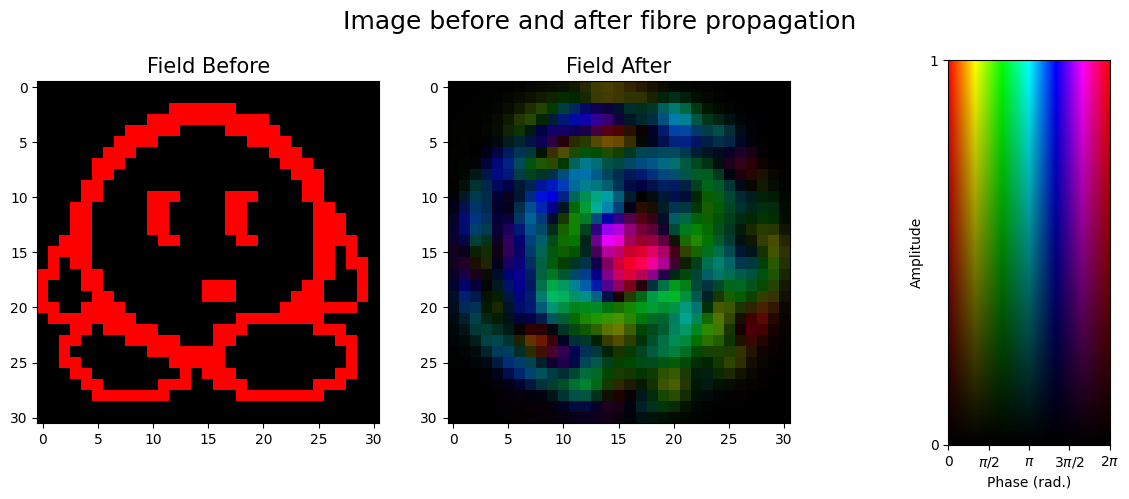

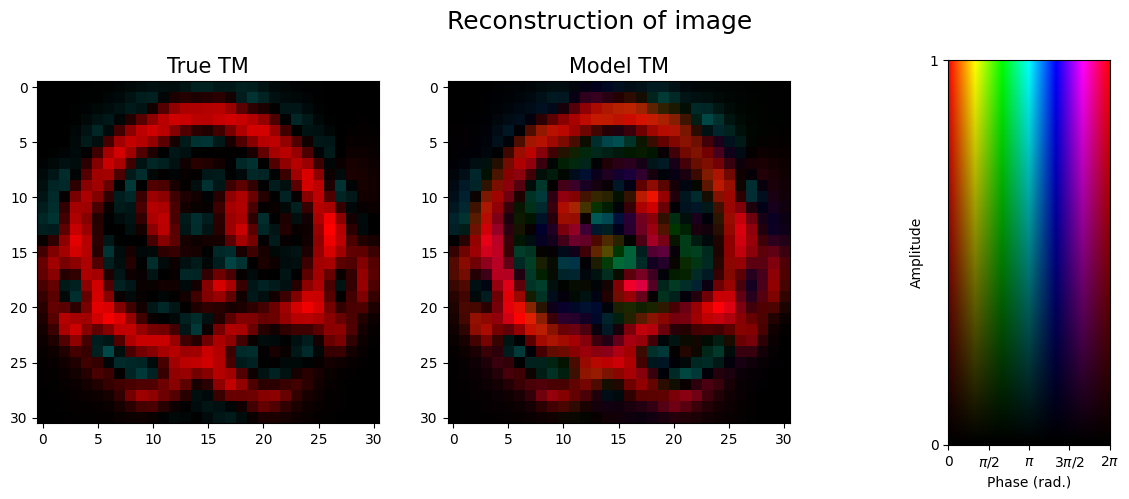

In [20]:
# Generate pixel TMs
pix_tm_model = pixel_TM(pims, model_TM)
pix_tm_true = fib.TM()
inv_tm_model = pixel_TM(pims, torch.linalg.inv(model_TM))
inv_tm_true = pixel_TM(pims.cpu(), torch.linalg.inv(true_TM))

# Pass an image through the fibre
image = image_to_field("Kirby")
image_out = unvectorise(pix_tm_true @ vectorise(image),31)
visualise2(image, image_out, "Image before and after fibre propagation")

# Run the inverse TM on the image for both the true TM and the model TM
true_inverse = unvectorise(inv_tm_true @ vectorise(image_out), 31)
model_inverse = unvectorise(inv_tm_model @ vectorise(image_out), 31)
visualise2(true_inverse, model_inverse, "Reconstruction of image", "True TM", "Model TM")

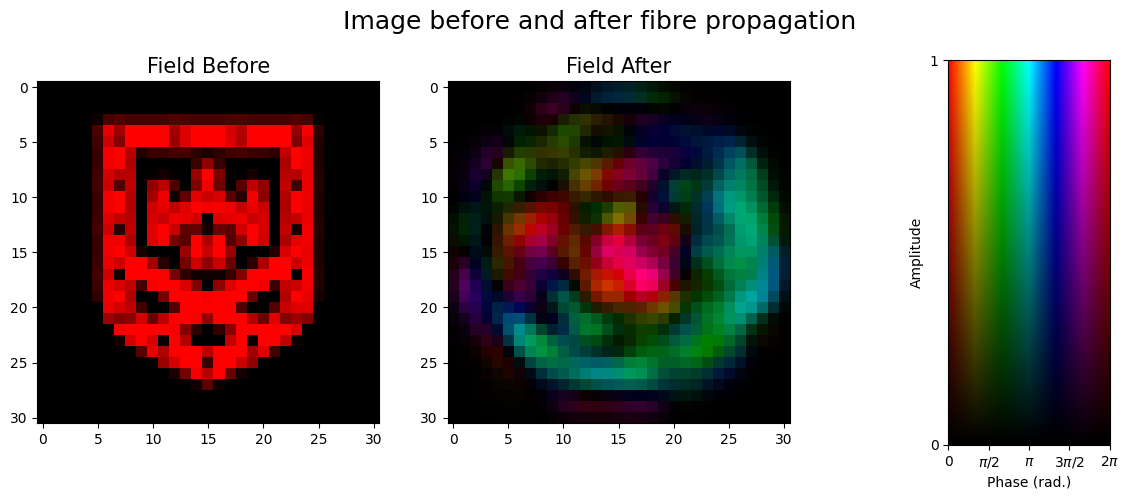

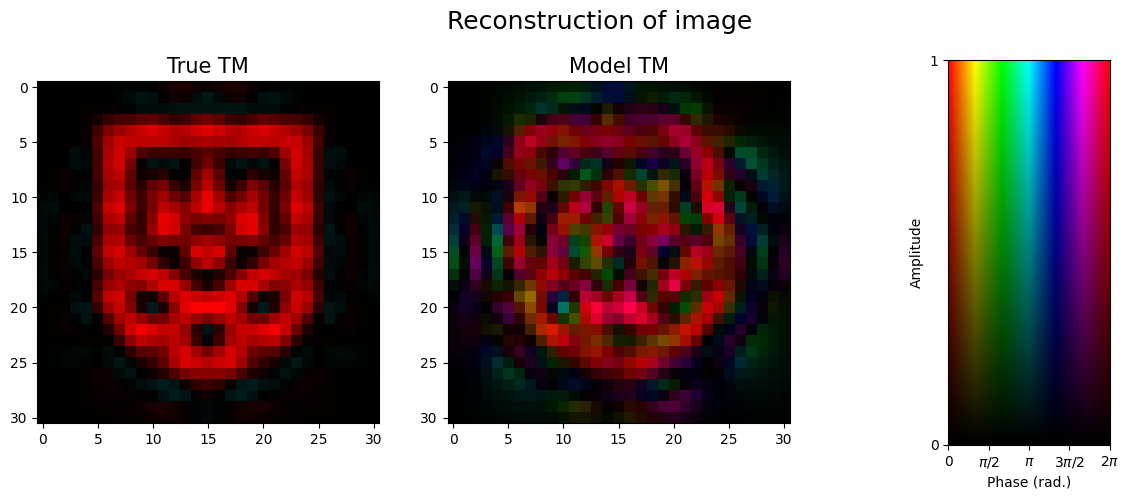

In [27]:
# Generate pixel TMs
pix_tm_model = pixel_TM(pims, model_TM)
pix_tm_true = fib.TM()
inv_tm_model = pixel_TM(pims, torch.linalg.inv(model_TM))
inv_tm_true = pixel_TM(pims.cpu(), torch.linalg.inv(true_TM))

# Pass an image through the fibre
image = image_to_field("UoE Logo Small")
image_out = unvectorise(pix_tm_true @ vectorise(image),31)
visualise2(image, image_out, "Image before and after fibre propagation")

# Run the inverse TM on the image for both the true TM and the model TM
true_inverse = unvectorise(inv_tm_true @ vectorise(image_out), 31)
model_inverse = unvectorise(inv_tm_model @ vectorise(image_out), 31)
visualise2(true_inverse, model_inverse, "Reconstruction of image", "True TM", "Model TM", name="UoE_recon_30bends.png", save=True)

The model can reproduce the images well enough for them to be visibly recognisable. A higher compression ratio will regain more image clarity. But, again, more complex fibre models (more segments and bends) are where the model struggles to recreate images, despite the forward pass TMs having very high correlations. Upon inversion, small values in the TM that don't have much effect on the forward pass of the model explode in value and cause the inverted TM to be incorrect. The assumption that the TM is unitary is broken which explains why these images struggle to be reconstructed.

# End of Notebook